## Shopping Data Analysis: Extracting Insights into Customer Behaviour and Trends <br>

1. **Project Summary** <br>

The goal of this project is to conduct a comprehensive EDA on a dataset of online store purchases. By studying customer demographics, product preferences, and purchasing behaviours, we aim to transform raw data into actionable strategic insights. This analysis addresses key questions about who our customers are, what they buy, and how they make decisions, providing a solid foundation for improving marketing strategies, inventory management, and customer satisfaction. <br>

2. **Analysis Objectives**

The analysis is divided into four main pillars to answer the following questions:

- Understanding Customers (Demographics Analysis): Which age groups and genders are most engaged? What are their interests?
- Sales and Product Analysis: What are the most popular products, categories, colours, and sizes? How do sales vary with seasons?
- Purchase and Payment Behaviour Analysis: How do customers prefer to pay? What is the impact of promotional offers on their purchasing behaviour.
- Customer Satisfaction and Loyalty Evaluation: How satisfied are customers with products and services? Are subscribed customers more loyal? <br>

3. **Methodology**

This notebook follows a structured methodology for data analysis, from preparation to conclusion:

- Environment Setup: Import required libraries and load the dataset.
- Exploratory Data Analysis (EDA): Examine the dataset to understand its structure, check data quality (missing values and duplicates), and extract initial descriptive statistics.
- Data Visualization: Convert numerical results into clear visualizations to answer the defined analysis questions.
- Insights Extraction: Summarize the main conclusions and strategic insights based on the performed analysis.

In [1]:
# Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading Data

shopping = pd.read_csv("C:/Users/GamerTech/Documents/Python/shopping_trends.csv")

shopping.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
shopping.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Bank Transfer,Store Pickup,No,No,33,Venmo,Quarterly


#### 1. General Information

In [4]:
print("--- General Information about the Dataset ---")
print(shopping.info())

--- General Information about the Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type    

To begin the analysis, I first examined the general structure of the dataset using the `.info()` method. This provides an overview of the number of entries, column details, data types, and memory usage.

The dataset contains **3900** entries (rows) and **19** columns.

Data Structure

- `Customer ID`: Unique identifier for each customer 
- `Age`: Age of the customer
- `Gender`: Customer's gender
- `Item Purchased`: Name of the purchased product
- `Category`: Category of the purchased item
- `Purchase Amount (USD)`: Purchase value in US dollars
- `Location`: Customer's location
- `Size`: Product size
- `Color`: Product colour
- `Season`: Relevant season for the product
- `Review Rating`: Customer's product rating
- `Subscription Status`: Whether the customer is subscribed
- `Payment Method`: Method of payment
- `Shipping Type`: Shipping method
- `Discount Applied`: Indicates if a discount was applied
- `Promo Code Used`: Indicates if a promo code was used
- `Previous Purchases`: Number of past purchases
- `Preferred Payment Method`: Customer's preferred payment method
- `Frequency of Purchases`: Frequency of purchases
<br><br>
Key Observations

- **No Missing Values:** All columns contain 3,900 non-null entries
- **Data Types:** 4 columns are numerical (`int64`), 1 column is decimal (`float54`), 14 columns are categorical (`object`)
- **Memory Usage:** 579 KB, which is lightweight and efficient for analysis

In [5]:
shopping.duplicated().sum()

np.int64(0)

In [6]:
shopping.nunique()

Customer ID                 3900
Age                           53
Gender                         2
Item Purchased                25
Category                       4
Purchase Amount (USD)         81
Location                      50
Size                           4
Color                         25
Season                         4
Review Rating                 26
Subscription Status            2
Payment Method                 6
Shipping Type                  6
Discount Applied               2
Promo Code Used                2
Previous Purchases            50
Preferred Payment Method       6
Frequency of Purchases         7
dtype: int64

In [7]:
print("--- Missing Values per Column ---")
shopping.isna().sum()

--- Missing Values per Column ---


Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

This confirms that the dataset is clean, consistent, and ready for further analysis.

#### 2. Descriptive Statistical Analysis of Numerical Columns

In [8]:
print("--- Descriptive Statistical Analysis of Numerical Columns ---")
shopping.describe()

--- Descriptive Statistical Analysis of Numerical Columns ---


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


**Analysis of Results:**

The descriptive statistics summary reveals the following patterns in the key numerical variables:

`Age`:

**Central Tendency:** The average customer age is 44.07 years, which is very close to the median (the 50th percentile value) of 44 years. This proximity indicates that the age distribution is nearly symmetrical, with no significant skew towards a specific age group.

**Range:** Customer ages range from 18 to 70 years, confirming that our customer base covers a wide spectrum of adult age segments. <br><br>

`Purchase Amount USD`:

**Central Tendency:** The average purchase amount is 59.76 and the median is 60. This indicates that most purchases are concentrated around this value.

**Range and Dispersion:** Purchase amounts range between 20 and 100. The standard deviation (23.68) suggests a reasonable variance in purchase values, but there are no obvious outliers (such as purchases in the thousands of dollars) that might affect the analysis. <br><br>

`Review Rating`:

**Central Tendency:** The average rating is 3.75, which points to a fairly good level of satisfaction among customers.

**Range:** Ratings range from 2.5 to 5.0. The absence of ratings below 2.5 could either mean that product quality is consistent or that completely dissatisfied customers do not leave reviews. <br><br>

`Previous Purchases`:

**Central Tendency:** The average number of previous purchases per customer is 25.35.

**Range and Dispersion:** The range extends from 1 to 50, indicating a healthy mix of new customers (with a single purchase) and highly loyal customers (with up to 50 previous purchases). <br><br>

`Key Conclusion`:

The descriptive statistics confirm that the numerical data is balanced and logical. There are no glaring anomalies or outliers that require immediate handling. The metrics point to a mature customer base with moderate spending, a good level of satisfaction, and a mix of new and loyal customers. These findings provide a solid foundation for moving on to a deeper analysis, such as exploring categorical variables and data visualization.

#### 3. Descriptive Statistical Analysis of Categorical Columns

In [9]:
print("--- Descriptive Statistical Analysis of Categorical Columns ---")
shopping.describe(include="object")

--- Descriptive Statistical Analysis of Categorical Columns ---


,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Preferred Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Credit Card,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,696,675,2223,2223,677,584


**Analysis of Results:** <br>

The statistical summary reveals significant insights into customer behaviour and preferences: <br><br>

`Gender`:

The data shows that Males represent the largest customer segment, accounting for 2,652 out of 3,900 customers (approximately 68%). <br><br>

`Item Purchased & Category`:

The Clothing category is the most dominant, comprising 1,737 purchases. Within this category, the Blouse is the most frequently purchased individual item (171 times). This indicates that clothing in general, and blouses in particular, are key sales drivers. <br><br>

`Location`:

Our customer base is distributed across 50 different locations. Montana is the most represented location in the dataset (96 customers). However, given the large total number of customers (3,900), this suggests that the customer base is geographically diverse rather than concentrated in a single area. <br><br>

`Size & Color`:

The most in-demand size is Medium (M), accounting for 1,755 purchases, making it a pivotal size for inventory management. The most common colour is Olive, likely followed by other popular colours. <br><br>

`Season`:

The Spring season has the highest number of purchases (999), which may indicate it is a peak season for sales or for launching new collections. <br><br>

`Subscription Status`:

The vast majority of customers (2,847) are not subscribed (No). This represents a significant opportunity to convert these customers into subscribers through targeted marketing campaigns. <br><br>

`Payment Method`:

Although there are 6 different payment methods, Credit Card and PayPal are most used and preferred (as the top value for Payment Method is Credit Card and for Preferred Payment Method is PayPal). This calls for a deeper analysis to compare the preferred method with the one acutally used. <br><br>

`Discount Applied & Promo Code Used`:

The majority of customers (2,223) did not use a discount or promo code. This could mean that purchasing decisions are not primarily driven by discounts, or it could be an opportunity to increase their use to boost sales. <br><br>

`Frequency of Purchases`:

The most common purchase frequency is "Every 3 Months", which reinforces the idea of a loyal customer base that makes periodic purchases. <br><br><br>


### Data Visualization

#### Questions to Understand Customers (Demographics Analysis)

##### 1. What is the average age of our customers?

In [10]:
average_age = shopping["Age"].mean()
print(f"The average age of the customers is: {average_age:.2f} years.")

The average age of the customers is: 44.07 years.


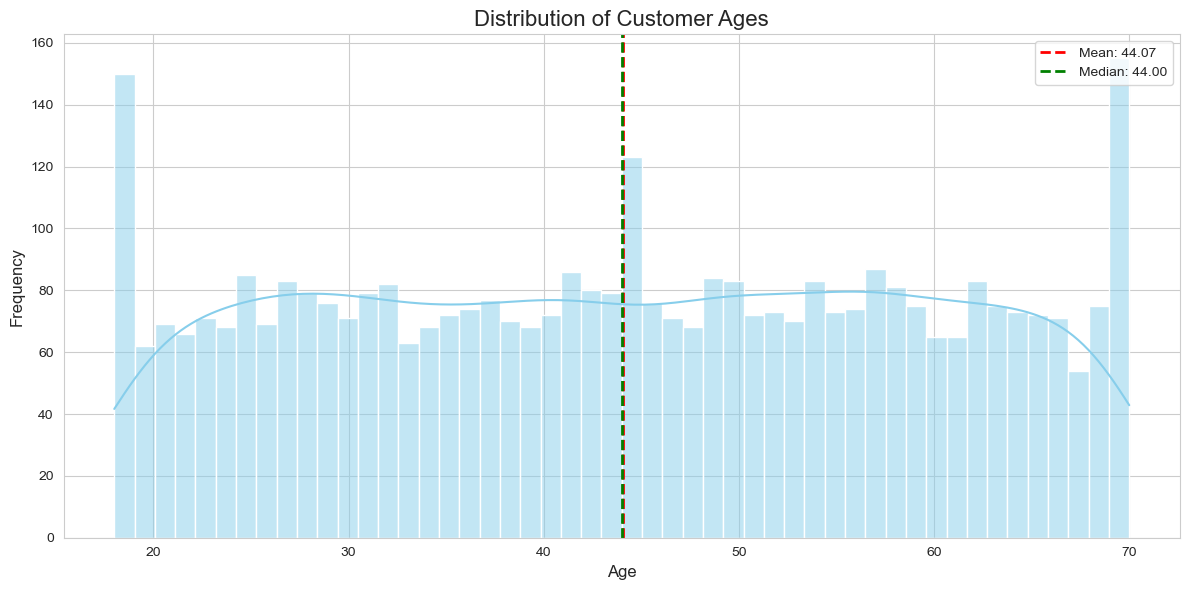

In [11]:
# Set a professional style for the plot
sns.set_style("whitegrid")

# Create a single plot figure
plt.figure(figsize=(12,6))

# Create the histogram and KDE plot
sns.histplot(data = shopping, x = "Age", kde = True, bins = 50, color = "skyblue")

# Add informative titles and labels
plt.title("Distribution of Customer Ages", fontsize = 16)
plt.xlabel("Age", fontsize = 12)
plt.ylabel("Frequency", fontsize = 12)

# Add a vertical line at the mean and median to highlight them
mean_score = shopping["Age"].mean()
median_score = shopping["Age"].median()

plt.axvline(mean_score, color = "red", linestyle = "--", linewidth = 2, label = f"Mean: {mean_score:.2f}")
plt.axvline(median_score, color = "green", linestyle = "--", linewidth = 2, label = f"Median: {median_score:.2f}")

# Add a legend to explain the vertical lines
plt.legend()

# Ensure everything fits nicely
plt.tight_layout()

plt.show()

##### 2. What is the age group that buys the most? And what does each age group care about?

In [12]:
# Create a new column for age groups
bins = [17, 29, 39, 49, 59, 71]
labels = ['Youth (18-29)', 'Adults (30-39)', 'Middle Age (40-49)', 'Seniors (50-59)', 'Elderly (60-70)']
shopping['Age Group'] = pd.cut(shopping['Age'], bins = bins, labels = labels, right = True)

# Find the most frequent purchasing age group
most_frequent_age_group = shopping['Age Group'].mode([0])
print(f"The age group that buys the most is: {most_frequent_age_group}")

# Show the most popular category for each age group
age_group_interests = shopping.groupby('Age Group')['Category'].agg(lambda x: x.mode()[0])
print("\n--- Interests of each age group (based on most purchased category) ---")
print(age_group_interests)

The age group that buys the most is: 0    Youth (18-29)
Name: Age Group, dtype: category
Categories (5, object): ['Youth (18-29)' < 'Adults (30-39)' < 'Middle Age (40-49)' < 'Seniors (50-59)' < 'Elderly (60-70)']

--- Interests of each age group (based on most purchased category) ---
Age Group
Youth (18-29)         Clothing
Adults (30-39)        Clothing
Middle Age (40-49)    Clothing
Seniors (50-59)       Clothing
Elderly (60-70)       Clothing
Name: Category, dtype: object


The data confirms that the "Youth (18-29)" age group is the most significant segment in terms of purchase frequency, making them the largest contributor to the total number of transactions.

To understand the interests of each age demographic, an analysis was conducted to identify the most purchased product category for each group. The result is remarkably consistent: "Clothing" emerged as the top category across all five age groups, from "Youth" to "Elderly."

Conclusion & Strategic Insight: This analysis reveals two critical insights: Core Customer Segment: The "Youth (18-29)" segment is the engine of our sales volume. Marketing campaigns, social media engagement, and new product launches should be primarily tailored to capture the attention and loyalty of this demographic. Universal Product Appeal: The dominance of "Clothing" across all ages signifies that it is the undeniable core of our business. While different age groups may purchase different styles of clothing, the category itself has universal appeal. This reinforces the need to maintain a strong and diverse clothing inventory. It also suggests that marketing efforts focused on clothing will resonate with the entire customer base, not just a single segment.

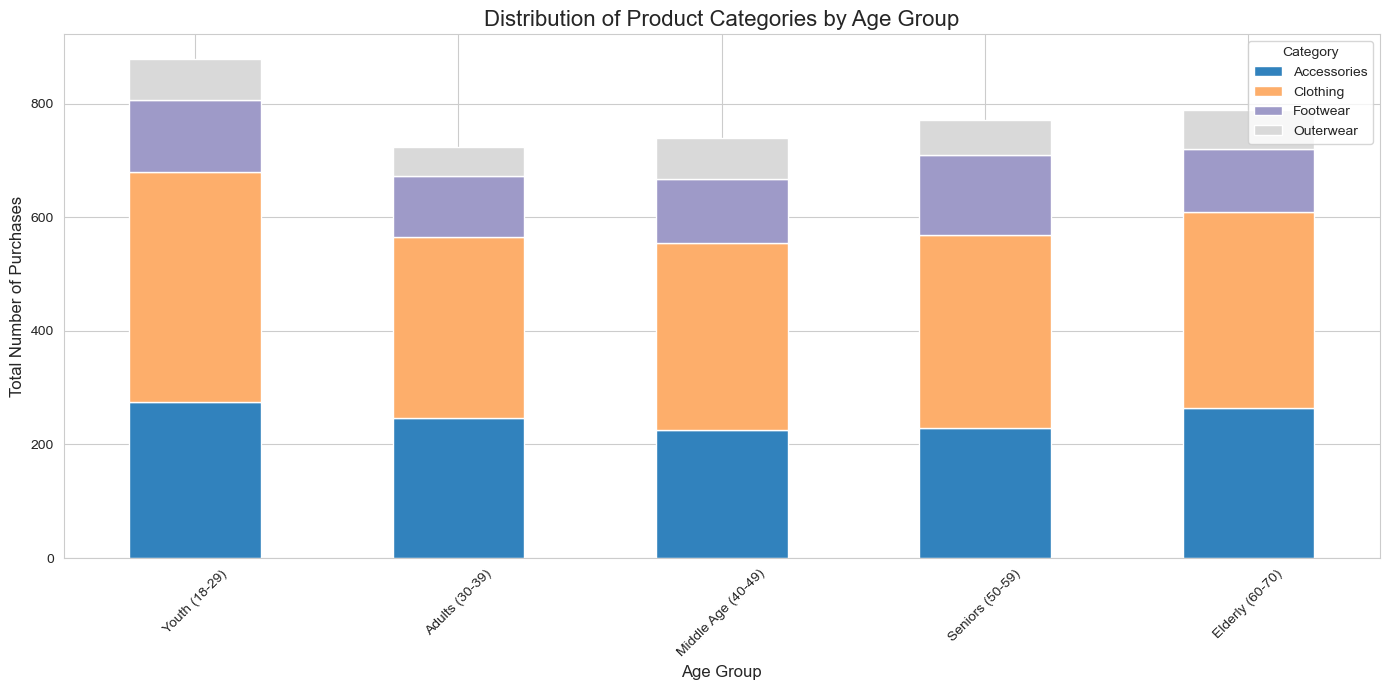

In [13]:
# Group the data
age_category_counts = shopping.groupby(["Age Group", "Category"]).size().unstack(fill_value = 0)

# Plot the results
age_category_counts.plot(kind = "bar", stacked = True, figsize=(14,7), colormap = "tab20c")
plt.title("Distribution of Product Categories by Age Group", fontsize = 16)
plt.xlabel("Age Group", fontsize = 12)
plt.ylabel("Total Number of Purchases", fontsize = 12)
plt.xticks(rotation = 45)
plt.legend(title = "Category", loc = "upper right")
plt.tight_layout()
plt.show()

##### 3. What is the percentage of male and female customers? And does one gender purchase more than the other?

In [14]:
# Calculate the percentage of male and female customers
gender_percentage = shopping['Gender'].value_counts(normalize=True)*100
print("Percentage of male and female customers:")
print(gender_percentage)
print(" ")
print(" ")

# Compare the average purchase amount between genders
gender_purchase_mean = shopping.groupby("Gender")["Purchase Amount (USD)"].mean()
print("--- Average purchase amount by gender ---")
print(gender_purchase_mean)

Percentage of male and female customers:
Gender
Male      68.0
Female    32.0
Name: proportion, dtype: float64
 
 
--- Average purchase amount by gender ---
Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64


Analysis:

Customer Distribution: The data clearly shows a significant imbalance in the gender distribution of our customer base. Males constitute a large majority at 68%, while females make up the remaining 32%. This indicates that our store currently attracts and serves a predominantly male audience.

Spending Behavior: Despite representing a smaller portion of the customer base, females spend slightly more on average per transaction (60.25)
compared to males (59.54).

Conclusion & Strategic Insight: This analysis reveals a crucial paradox and a significant strategic opportunity: High-Value Segment: Although smaller in number, our female customers are a high-value segment, as they demonstrate a higher average purchase value (APV). Each female customer, on average, contributes slightly more revenue per purchase than a male customer.

Untapped Market Potential: The combination of a lower customer count and higher spending per transaction strongly suggests that the female market is underserved and holds significant growth potential. If we can increase our appeal to female customers and grow their segment share, it could lead to a disproportionately large increase in overall revenue.

Recommendation: The business should investigate why female customers spend more and why there are fewer of them. A targeted strategy should be developed to attract more female customers. This could include: Expanding product lines that appeal to women. Launching marketing campaigns specifically targeting female demographics. Analyzing the purchasing behavior of the existing female customer base to understand their preferences better.

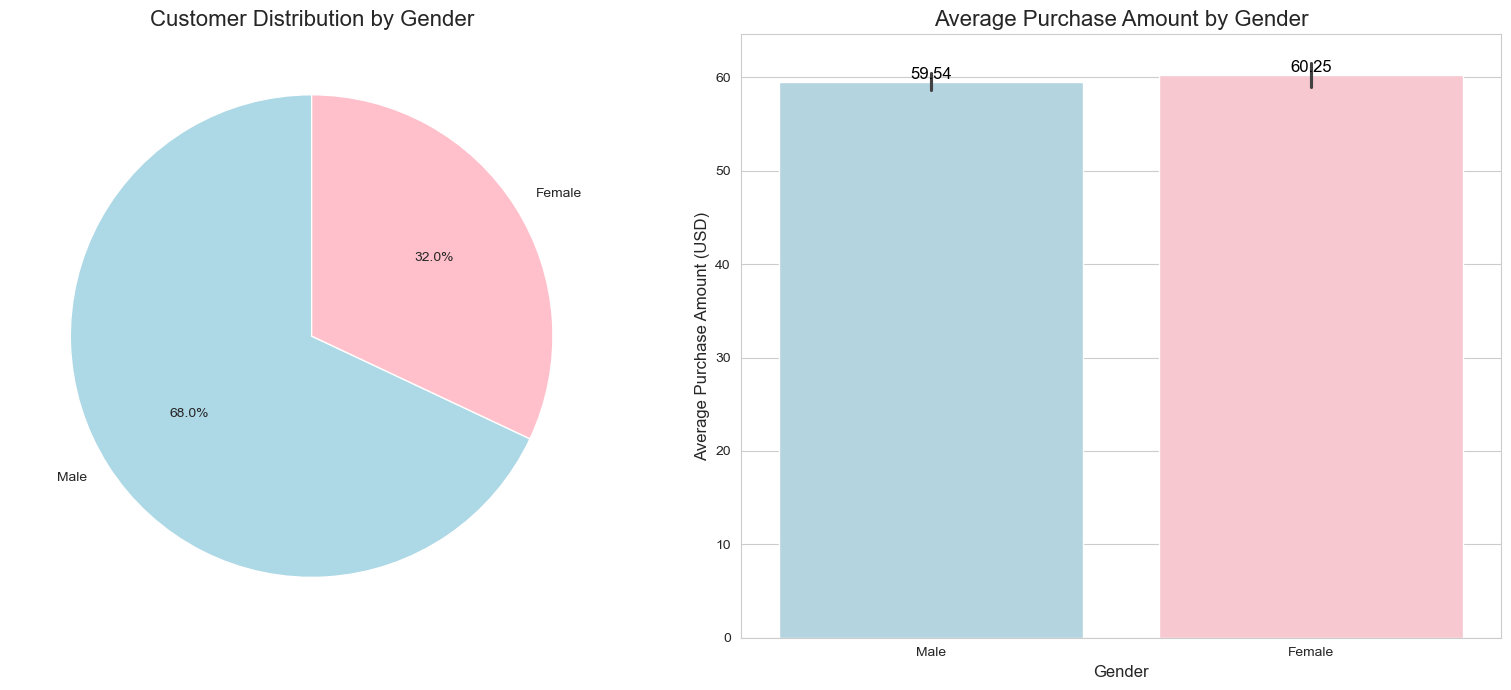

In [15]:
# Create a figure with two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16,7))

# First plot: Gender distribution (Pie Chart)
gender_counts = shopping['Gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'pink'])
axes[0].set_title('Customer Distribution by Gender', fontsize = 16)

# Second plot: Average purchase amount (Bar Chart)
# We store the barplot in a variable 'barplot' to access its properties
barplot = sns.barplot(data=shopping, x='Gender', y='Purchase Amount (USD)', ax=axes[1], palette=['lightblue', 'pink'])
axes[1].set_title('Average Purchase Amount by Gender', fontsize=16)
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Average Purchase Amount (USD)', fontsize=12)

# Add labels above the bars
# We iterate over each bar in the barplot
for bar in barplot.patches:
    # Get the height of the bar (which is the y-value, the average purchase amount)
    y_value = bar.get_height()

    # Get the x-coordinate of the bar's center
    x_value = bar.get_x() + bar.get_width() / 2

    # Place the text slightly above the bar
    # The format '{:.2f}' will format the number to two decimal places (eg: 59.85)
    axes[1].text(x_value, y_value, f'{y_value:.2f}',
                ha = 'center',  # Horizontal alignment
                va = 'bottom',  # Vertical alignment
                fontsize = 12,
                color = 'black')

plt.tight_layout()
plt.show()

##### 4. What is the most purchased product by female and male customers?

In [16]:
# Most purchased product by female customers
female_top_item = shopping[shopping['Gender'] == 'Female']['Item Purchased'].mode()[0]
print(f"The most purchased product by female customers is: {female_top_item}")

# Most purchased product by male customers
male_top_item = shopping[shopping['Gender'] == 'Male']['Item Purchased'].mode()[0]
print(f"The most purchased product by male customers is: {male_top_item}")

The most purchased product by female customers is: Blouse
The most purchased product by male customers is: Pants


Analysis:

To further understand the specific preferences of each gender, the analysis identified the single most purchased item for both males and females.

The results show a clear and traditional preference: The most purchased item by females is the "Blouse." The most purchased item by males is "Pants." 

Conclusion & Strategic Insight:

This finding provides a clear, actionable insight for inventory and marketing strategies. Inventory Management: "Blouses" and "Pants" should be considered core, high-priority items in our inventory. We must ensure a consistent and diverse stock of these items at all times, including various sizes, colors, and styles, to meet the high demand from our primary gender segments. Targeted Marketing: This knowledge allows for highly specific and effective marketing campaigns. For example:

Email campaigns targeting female customers can feature "New Arrivals: Blouses." Social media ads targeting male customers can highlight "Best-Selling Pants." By aligning our stock and marketing efforts with these proven preferences, we can directly cater to the primary needs of our customers, likely leading to increased sales and customer satisfaction.

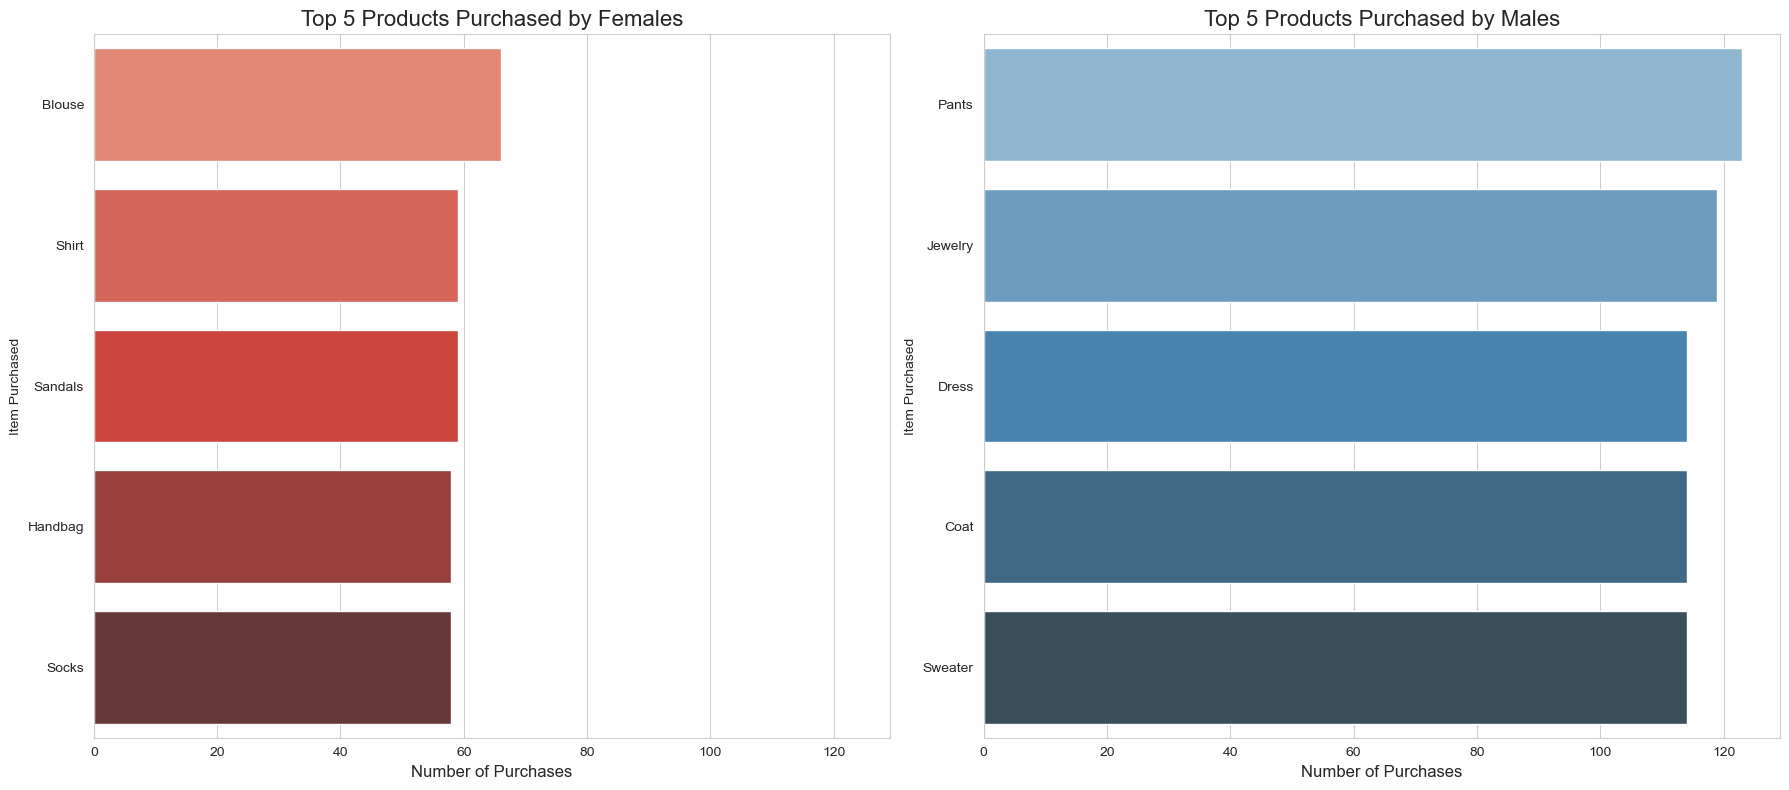

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18,8), sharex=True)

# Top 5 products purchased by female customers
female_top_5 = shopping[shopping['Gender'] == 'Female']['Item Purchased'].value_counts().head(5)
sns.barplot(x = female_top_5.values, y = female_top_5.index, ax=axes[0], palette='Reds_d')
axes[0].set_title('Top 5 Products Purchased by Females', fontsize=16)
axes[0].set_xlabel('Number of Purchases', fontsize=12)

# Top 5 products purchased by male customers
male_top_5 = shopping[shopping['Gender'] == 'Male']['Item Purchased'].value_counts().head(5)
sns.barplot(x = male_top_5.values, y = male_top_5.index, ax=axes[1], palette='Blues_d')
axes[1].set_title('Top 5 Products Purchased by Males', fontsize=16)
axes[1].set_xlabel('Number of Purchases', fontsize=12)

plt.tight_layout()
plt.show()

##### 5. What are the locations most of our customers come from?

In [18]:
# Display the top 10 locations by number of customers
top_10_locations = shopping['Location'].value_counts().head(10)
print(" Top 10 Locations Where Customers Come From: ")
print(top_10_locations)

 Top 10 Locations Where Customers Come From: 
Location
Montana       96
California    95
Idaho         93
Illinois      92
Alabama       89
Minnesota     88
New York      87
Nevada        87
Nebraska      87
Delaware      86
Name: count, dtype: int64


Analysis: An analysis of customer locations reveals the top 10 states contributing the highest number of customers to our business. Montana and California lead the list, with 96 and 95 customers respectively.

The distribution among the top 10 locations is remarkably even, with customer counts ranging from 96 down to 86. There is no single location that overwhelmingly dominates the customer base.

Conclusion & Strategic Insight: Geographically Diverse Customer Base: The primary takeaway is that our customer base is not concentrated in one or two major hubs. Instead, we have a healthy, distributed presence across multiple states. This is a positive sign of broad market appeal and reduces the risk of being over-reliant on a single regional economy.

Key Markets: The states listed (Montana, California, Idaho, Illinois, etc.) represent our core markets. These are areas where our brand and products currently have the strongest traction.

Opportunities for Targeted Growth: Strengthen Core Markets: Marketing efforts, including localized digital ads or promotions, could be focused on these top 10 states to further solidify our presence and encourage word-of-mouth growth.

Analyze Regional Preferences: The next logical step is to investigate if purchasing behavior differs in these key markets, which could unlock opportunities for region-specific product recommendations or campaigns.

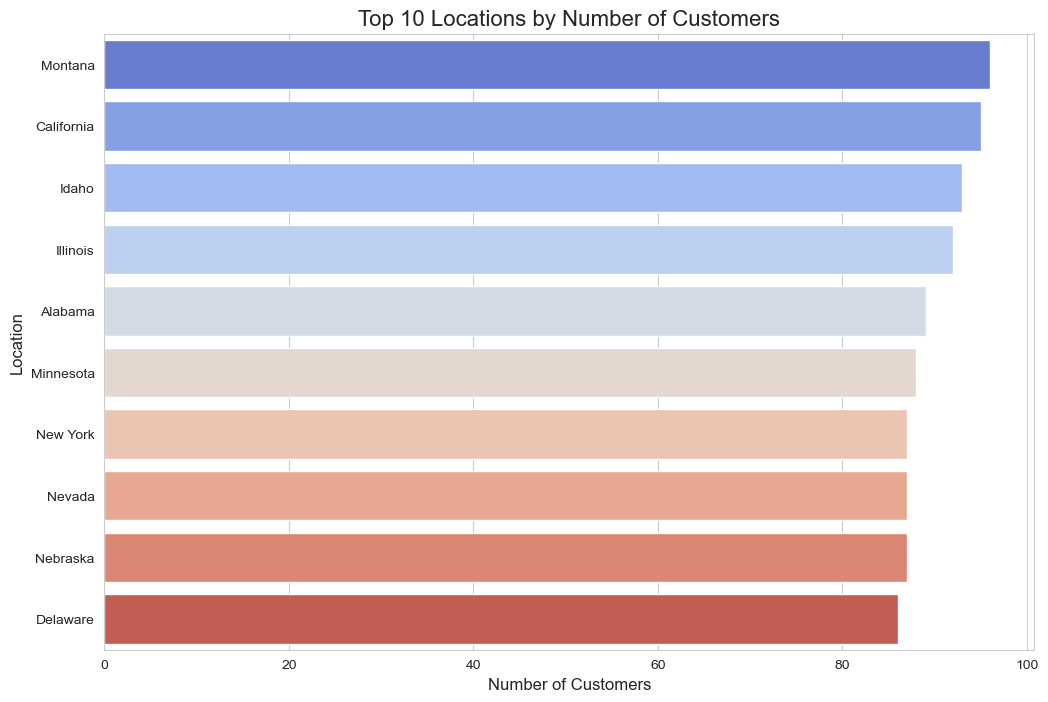

In [19]:
plt.figure(figsize=(12, 8))
top_10_locations = shopping['Location'].value_counts().head(10)
sns.barplot(x=top_10_locations.values, y=top_10_locations.index, palette='coolwarm')
plt.title('Top 10 Locations by Number of Customers', fontsize=16)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.show()

##### 6. Is there a relationship between the customer's geographical location and the product category they purchase?

In [20]:
# Identify top 10 locations
top_locations_list = shopping['Location'].value_counts().head(10).index

# Filter the data to include only these locations
shopping_top_locations = shopping[shopping['Location'].isin(top_locations_list)]

# Display the most purchased category in each of the top 10 locations
location_category_preference = shopping_top_locations.groupby('Location')['Category'].agg(lambda x: x.mode()[0])
print("Preferred category in each of the top 10 locations:")
print(location_category_preference)

Preferred category in each of the top 10 locations:
Location
Alabama          Clothing
California       Clothing
Delaware         Clothing
Idaho            Clothing
Illinois         Clothing
Minnesota        Clothing
Montana          Clothing
Nebraska      Accessories
Nevada           Clothing
New York         Clothing
Name: Category, dtype: object


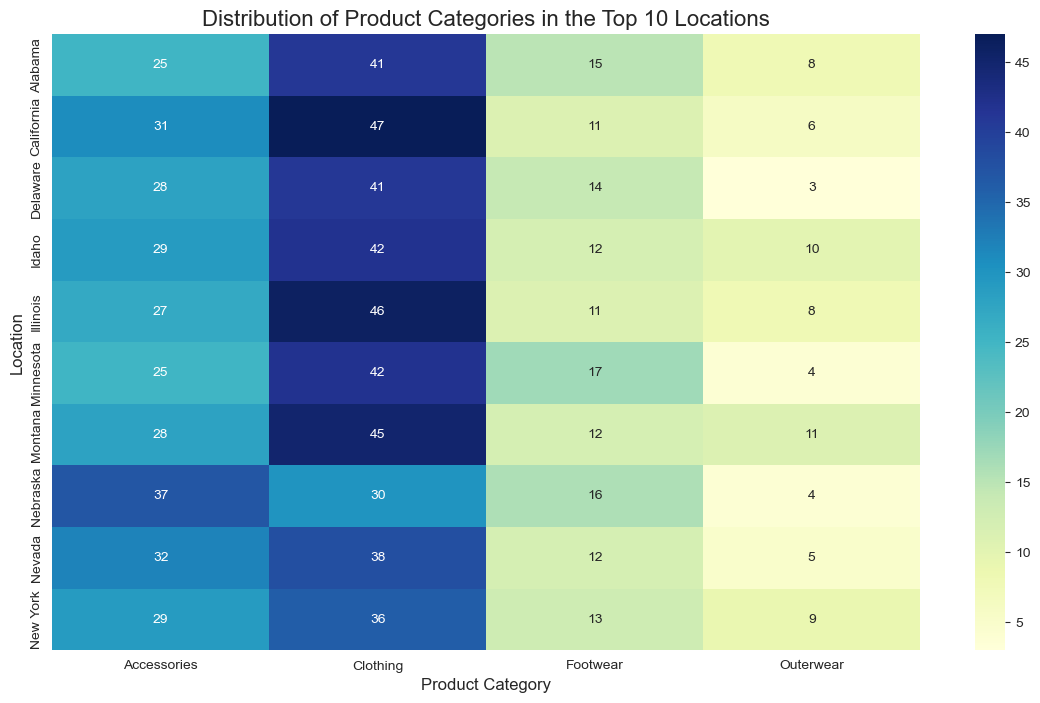

In [21]:
# First group the data
top_10_locations_list = shopping['Location'].value_counts().head(10).index
shopping_top_locations = shopping[shopping['Location'].isin(top_10_locations_list)]
location_category_pivot = pd.crosstab(index=shopping_top_locations['Location'], columns=shopping_top_locations['Category'])

# Now, plot the heatmap
plt.figure(figsize=(14,8))
sns.heatmap(location_category_pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Distribution of Product Categories in the Top 10 Locations', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.show()

### Questions for Sales and Product Analysis

##### 1. What are the top selling products, and which categories generate the highest revenue?

In [22]:
# A) Top 10 most sold products (by quantity)
top_10_items = shopping['Item Purchased'].value_counts().head(10)
print("\n--- Top 10 Most Sold Products (by quantity) ---")
print(top_10_items)

# B) Top revenue-generating categories (by total sales)
top_revenue_categories = shopping.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
print("\n" + "="*50 + "\n")
print("--- Top Revenue-Generating Categories ---")
print(top_revenue_categories)
print("\n" + "="*50 + "\n")


--- Top 10 Most Sold Products (by quantity) ---
Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: int64


--- Top Revenue-Generating Categories ---
Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64




Analysis:

Top-Selling Items: An analysis of individual product sales reveals a highly competitive and evenly distributed landscape. "Blouse," "Pants," and "Jewelry" are tied as the top-selling items by quantity, each with 171 units sold. The top 10 products all have very similar sales figures, indicating a broad appeal across our product catalog rather than a single "hero" product.

Top-Grossing Categories: When sales are aggregated by category to determine total revenue, a clear hierarchy emerges. Clothing is the undisputed leader, generating 104,264 in revenue. Accessories follows a strong second, with 74,200 in revenue. Footwear and Outwear are smaller, yet still significant, contributors.

Conclusion & Strategic Insight: Clothing is the Financial Engine: While individual best-sellers are spread across categories (e.g., Jewelry from Accessories), the "Clothing" category as a whole is the financial backbone of the business. Its revenue is substantially higher than any other category, confirming it as our core market. Broad Catalog Strength: The even distribution of sales among the top 10 items is a sign of a healthy and well-curated product catalog. We are not overly reliant on a single item, which reduces risk. It suggests customers are exploring and purchasing a wide range of products.

Recommendation: The strategy should be twofold: Protect the Core: Continue to invest heavily in the "Clothing" category to maintain its lead. Grow the Runner-Up: "Accessories" represents a significant revenue stream and should be nurtured. Given that "Jewelry" is a top-selling item, there is a clear opportunity to promote other products within the Accessories category to further boost its contribution to the bottom line.

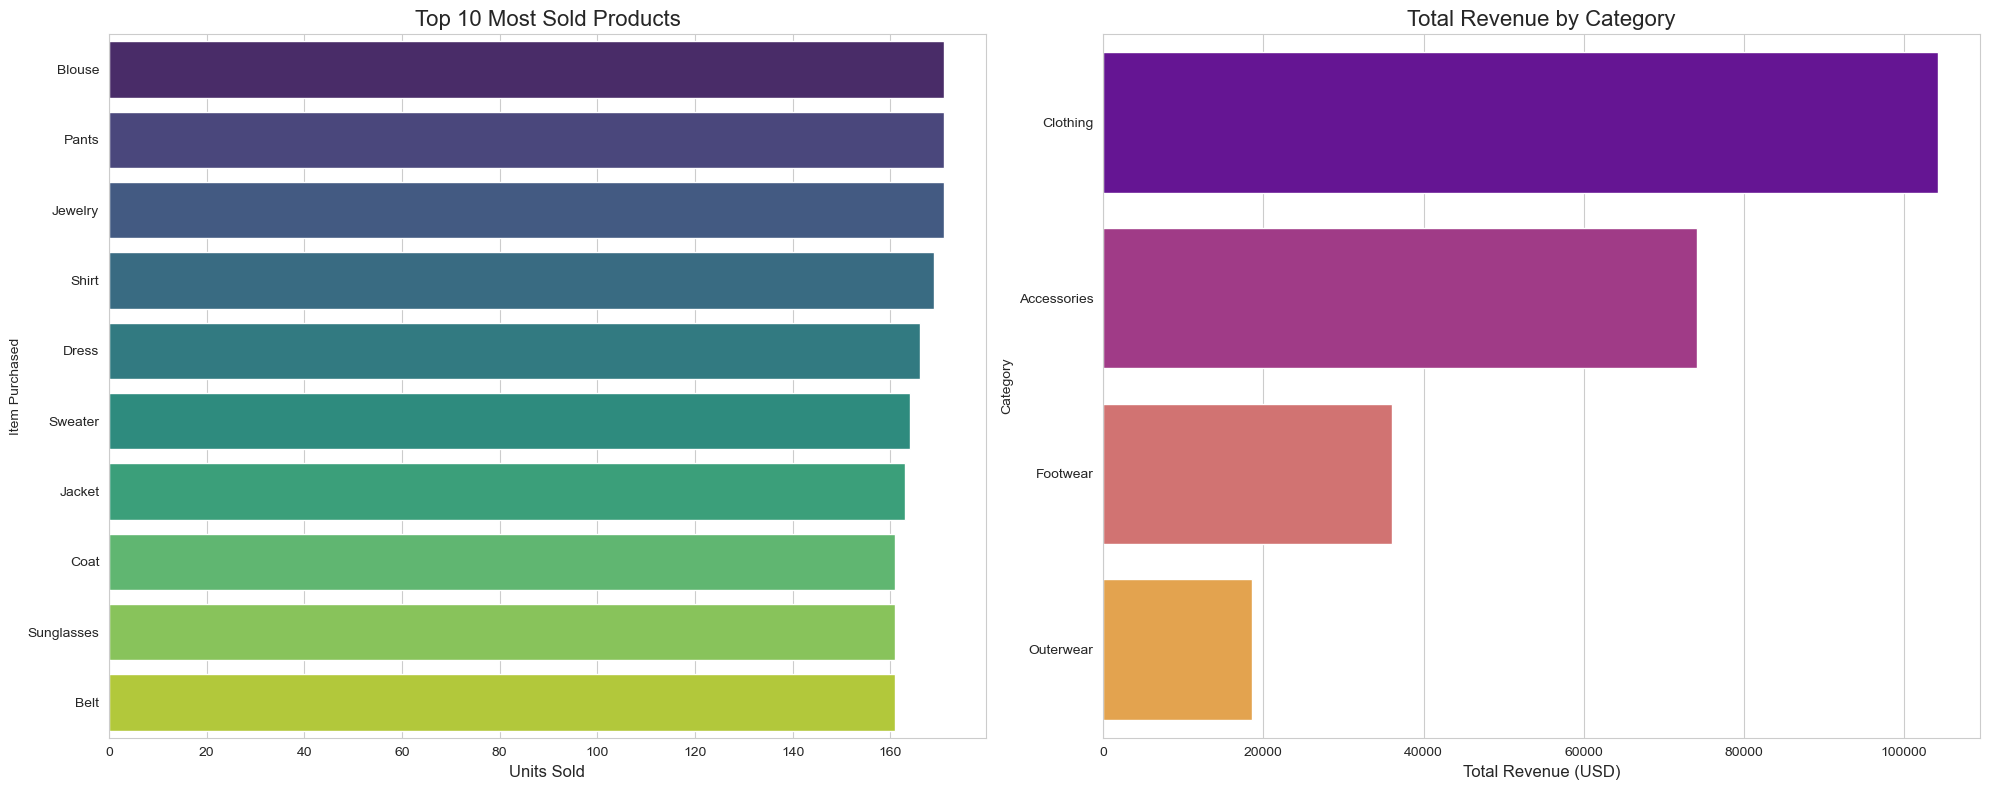

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20,8))

# First plot: Top 10 most sold products
sns.barplot(x=top_10_items.values, y=top_10_items.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Most Sold Products', fontsize=16)
axes[0].set_xlabel('Units Sold', fontsize=12)

# Second plot: Revenue by Category
sns.barplot(x=top_revenue_categories.values, y=top_revenue_categories.index, ax=axes[1], palette='plasma')
axes[1].set_title('Total Revenue by Category', fontsize=16)
axes[1].set_xlabel('Total Revenue (USD)', fontsize=12)

plt.tight_layout()
plt.show()

##### 2. What is the average purhcase amount per order?

In [24]:
average_purchase_amount = shopping['Purchase Amount (USD)'].mean()
print(f"The average purchase amount per order is: ${average_purchase_amount:.2f}")

The average purchase amount per order is: $59.76


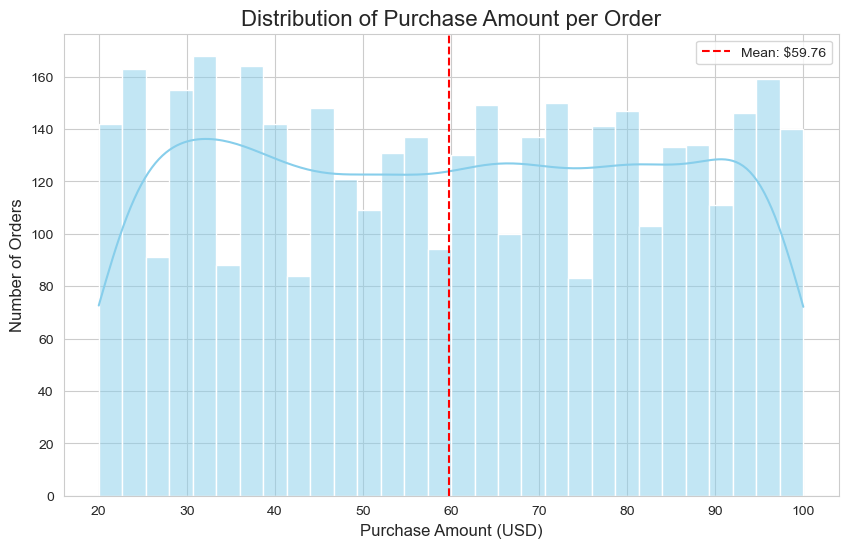

In [25]:
plt.figure(figsize=(10,6))
sns.histplot(shopping['Purchase Amount (USD)'], bins=30, kde=True, color='skyblue')
plt.axvline(average_purchase_amount, color='red', linestyle='--', label=f'Mean: ${average_purchase_amount:.2f}')
plt.title('Distribution of Purchase Amount per Order', fontsize=16)
plt.xlabel('Purchase Amount (USD)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.legend()
plt.show()

##### 3. Do sales differ by season? And what are the best-selling products in each season?

In [26]:
# A) Sales by Season
sales_by_season = shopping['Season'].value_counts()
print("--- Total Sales by Season ---")
print(sales_by_season)

# B) Best-selling product in each season
top_item_per_season = shopping.groupby('Season')['Item Purchased'].agg(lambda x: x.mode()[0])
print("\n" + "="*50 + "\n")
print("--- Best-selling Product in Each Season ---")
print(top_item_per_season)
print("\n" + "="*50 + "\n")

--- Total Sales by Season ---
Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64


--- Best-selling Product in Each Season ---
Season
Fall          Jacket
Spring       Sweater
Summer         Pants
Winter    Sunglasses
Name: Item Purchased, dtype: object




Analysis:

Sales Volume by Season: The analysis of sales distribution across seasons shows a remarkably stable and consistent pattern. Spring leads with a slight edge (999 purchases), but all four seasons exhibit very similar sales volumes. This indicates that the business does not have a significant "peak" or "off-peak" season; demand is steady year-round.

Seasonal Product Preferences: Despite the consistent sales volume, customer preferences for specific items change distinctly with the seasons: Spring: The most purchased item is the Sweater. Summer: The top seller shifts to Pants. Fall: Jacket becomes the most popular item. Winter: Interestingly, Sunglasses emerge as the best-selling product.

Conclusion & Strategic Insight: Stable Year-Round Business: The lack of significant seasonal fluctuation is a major strength. It simplifies financial forecasting and inventory management, as the business can rely on a steady stream of demand throughout the year without drastic seasonal hiring or stock reduction.

Season-Driven Product Strategy is Crucial: The key insight is that what customers buy is highly dependent on the season, even if how much they buy remains constant. The top-selling items align logically with typical seasonal needs (e.g., Jacket in Fall). The "Winter Sunglasses" Anomaly: The finding that Sunglasses are the top seller in Winter is counter-intuitive and warrants attention. This could be due to several factors: winter sun, ski trips, customers in warmer climates, or gift-giving. This anomaly suggests that Sunglasses are a year-round, high-demand accessory, not just a summer item.

Recommendation: Marketing and inventory strategies must be agile and season-aware. Inventory Planning: Stock levels for key items (Sweaters, Pants, Jackets, Sunglasses) should be ramped up just before their respective peak seasons. Marketing Campaigns: Promotional efforts should be aligned with seasonal preferences. For example, a "Get Ready for Fall" campaign in late summer should feature jackets. The surprising success of sunglasses in winter should be leveraged, perhaps with a "Winter Sun" or "Holiday Getaway" marketing angle.

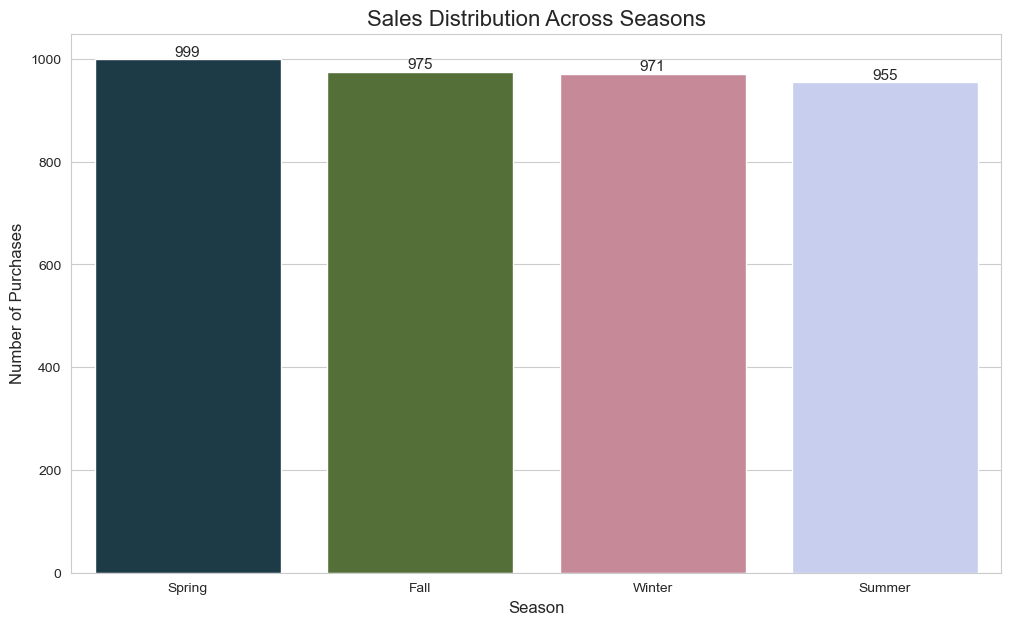

In [27]:
# Using a bar chart to show sales by season
plt.figure(figsize=(12,7))
ax = sns.countplot(data=shopping, x='Season', order=sales_by_season.index, palette='cubehelix')

# Add numbers above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=11)

plt.title('Sales Distribution Across Seasons', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Purchases', fontsize=12)
plt.show()

##### 4. What are the most requested sizes for women and men?

In [28]:
# A) Most requested sizes for women
female_top_sizes = shopping[shopping['Gender'] == 'Female']['Size'].value_counts()
print("--- Most Requested Sizes for Women ---")
print(female_top_sizes)

# B) Most requested sizes for men
male_top_sizes = shopping[shopping['Gender'] == 'Male']['Size'].value_counts()
print("\n" + "="*50 + "\n")
print("--- Most Requested Sizes for Men ---")
print(male_top_sizes)
print("\n" + "="*50 + "\n")

--- Most Requested Sizes for Women ---
Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


--- Most Requested Sizes for Men ---
Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64




Analysis:

To optimize inventory, an analysis was conducted to determine the most frequently purchased sizes for both male and female customers. The results show a clear and consistent pattern across both genders: For both women and men, Medium (M) is unequivocally the most popular size, followed by Large (L), then Small (S), and finally Extra Large (XL). The demand for size Medium among men is particularly pronounced, accounting for 1,165 units, which is significantly higher than any other size-gender combination.

Conclusion & Strategic Insight: Medium is the Core Size: Size Medium is the anchor of our inventory. It is the most critical size to have in stock at all times for all products, as it satisfies the largest segment of our customer base for both genders. Prioritized Stocking Ratio: The data provides a clear blueprint for inventory planning. For every product available to both genders, the stocking ratio should follow the M > L > S > XL hierarchy. Running out of stock for size M would have a much greater negative impact on sales than running out of stock for size XL.

Recommendation: Inventory management and purchasing decisions must be directly informed by this data. Purchasing Orders: When ordering new products, the quantity for size Medium should be the highest, followed by Large, Small, and XL in descending order. Safety Stock: A higher level of "safety stock" should be maintained for size M to prevent stockouts and lost sales. Sales & Clearance: Conversely, size XL could be a candidate for earlier inclusion in clearance sales if inventory needs to be moved, as it represents the slowest-moving size category.

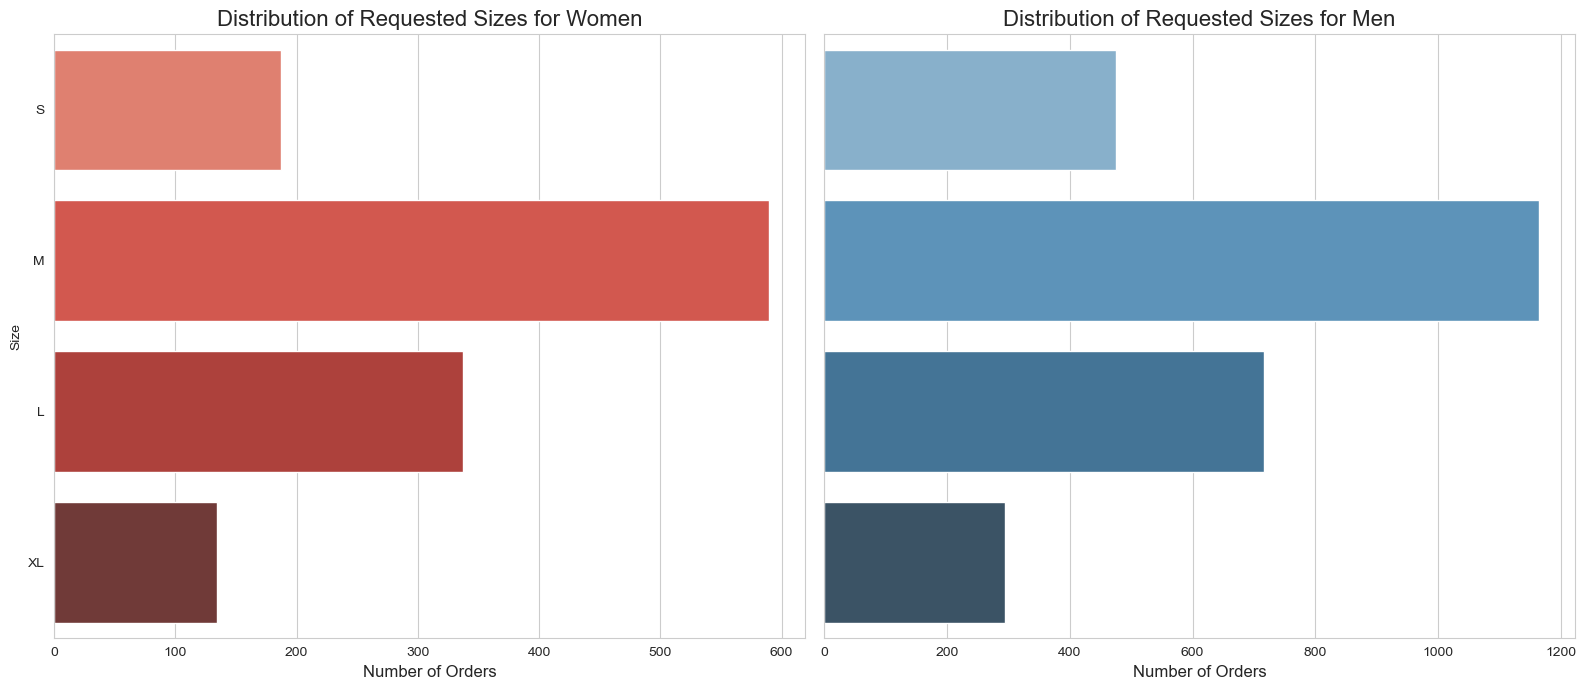

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16,7), sharey=True)

# Chart 1: Women's sizes
sns.barplot(x=female_top_sizes.values, y=female_top_sizes.index, ax=axes[0], palette='Reds_d', order=['S','M','L','XL'])
axes[0].set_title('Distribution of Requested Sizes for Women', fontsize=16)
axes[0].set_xlabel('Number of Orders', fontsize=12)

# Chart 2: Men's sizes
sns.barplot(x=male_top_sizes.values, y=male_top_sizes.index, ax=axes[1], palette='Blues_d', order=['S', 'M', 'L', 'XL'])
axes[1].set_title('Distribution of Requested Sizes for Men', fontsize=16)
axes[1].set_xlabel('Number of Orders', fontsize=12)

plt.tight_layout()
plt.show()

##### 5. What are the most requested colors for women and men?

In [30]:
# A) Top 5 colors for women
female_top_colors = shopping[shopping['Gender'] == 'Female']['Color'].value_counts().head(5)
print("--- Top 5 Colors for Women ---")
print(female_top_colors)

# B) Top 5 colors for men
male_top_colors = shopping[shopping['Gender'] == 'Male']['Color'].value_counts().head(5)
print("\n" + "="*50 + "\n")
print("--- Top 5 Colors for Men ---")
print(male_top_colors)

--- Top 5 Colors for Women ---
Color
Yellow     60
Olive      59
Pink       58
Magenta    57
Green      56
Name: count, dtype: int64


--- Top 5 Colors for Men ---
Color
Silver    121
Cyan      119
Teal      119
Olive     118
Yellow    114
Name: count, dtype: int64


Analysis:

An analysis of the top 5 most purchased colors for each gender reveals distinct and valuable insights into customer preferences. For Women: The preferred color palette is vibrant and warm. Yellow leads, followed closely by Olive, Pink, Magenta, and Green. The demand is very evenly distributed among these top colors. For Men: The color preference shifts towards a cooler, more metallic or blue-green spectrum. Silver is the top choice, with Cyan, Teal, and Olive being almost equally popular. Yellow also appears in the top 5 for men, but the core preference is different.

Conclusion & Strategic Insight: Divergent Color Palettes: Unlike size preferences which were consistent, color preferences are highly gender-specific. This means a "one-size-fits-all" approach to color selection for products will not be effective. "Olive" as a Crossover Color: The color Olive is the only one to appear in the top 5 for both men and women. This makes it a uniquely versatile and safe "unisex" color choice for products that are marketed to both genders.

Actionable Insights for Product Design & Marketing: Product Development: When designing or ordering gender-specific products, this data provides a clear guide. For a new line of dresses, incorporating Yellow, Pink, and Magenta would be a data-driven decision. For a new line of men's shirts, focusing on Silver, Cyan, and Teal would be wise. Visual Merchandising: Website banners, social media posts, and email campaigns can be tailored visually. Ads targeting women can feature models wearing bright, warm colors, while ads targeting men can showcase the cooler palette.

Recommendation: Product and marketing teams should use this analysis as a direct input for their strategies. Prioritizing the top-ranked colors for each gender in new collections and promotional materials is likely to increase product appeal and conversion rates. The unique status of "Olive" should be leveraged for any unisex product offerings.

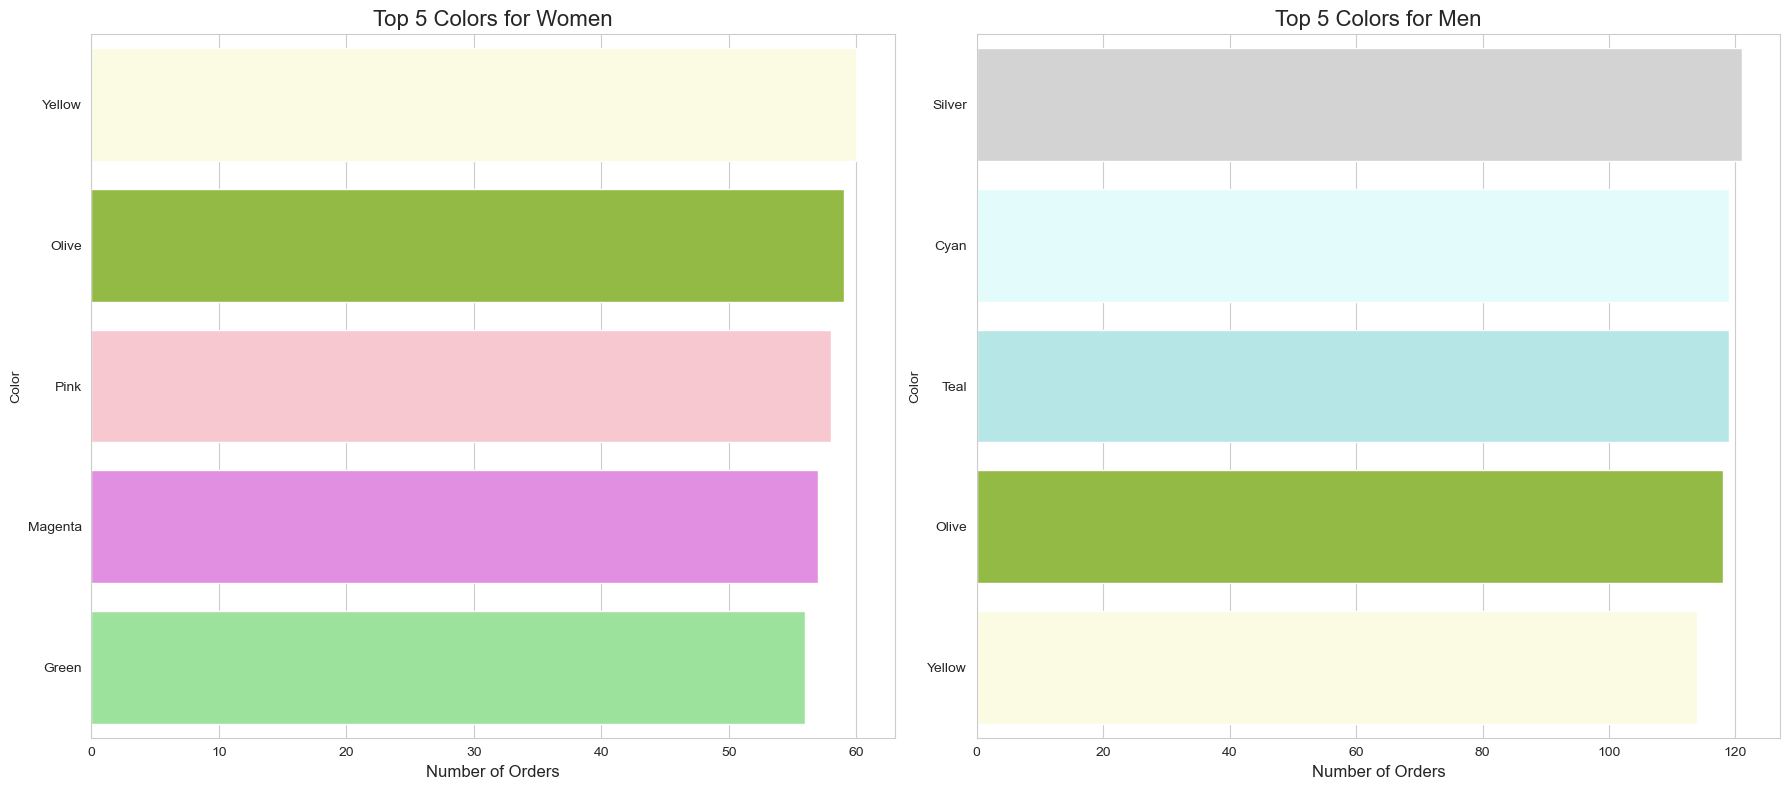

In [31]:
# We specify a lighter version for each color that appears in the data
light_colors_map = {
    "Yellow": "lightyellow",
    "Olive": "yellowgreen",
    "Pink": "pink",
    "Magenta": "violet",
    "Green": "lightgreen",
    "Silver": "lightgrey",
    "Cyan": "lightcyan",
    "Teal": "paleturquoise"
}

# Female's Palette
female_palette = [light_colors_map[color] for color in female_top_colors.index]

# Male's Palette
male_palette = [light_colors_map[color] for color in male_top_colors.index]

fig, axes = plt.subplots(1, 2, figsize=(18,8))

# Chart 1: Women's colors
sns.barplot(x=female_top_colors.values, y=female_top_colors.index, ax=axes[0], palette=female_palette)
axes[0].set_title('Top 5 Colors for Women', fontsize=16)
axes[0].set_xlabel('Number of Orders', fontsize=12)

# Chart 2: Men's colors
sns.barplot(x=male_top_colors.values, y=male_top_colors.index, ax=axes[1], palette=male_palette)
axes[1].set_title('Top 5 Colors for Men', fontsize=16)
axes[1].set_xlabel('Number of Orders', fontsize=12)

plt.tight_layout()
plt.show()

##### 6. What are the most requested colors for products shared between men and women?

In [32]:
# --- Shared Products Between Men and Women ---
# Products purchased by men
male_items = set(shopping[shopping['Gender'] == 'Male']['Item Purchased'].unique())

# Products purchased by women
female_items = set(shopping[shopping['Gender'] == 'Female']['Item Purchased'].unique())

# Shared products
common_items = male_items.intersection(female_items)
print("--- Shared Products Between Men and Women ---")
print(common_items)

# --- Filter only shared products ---
common_df = shopping[shopping['Item Purchased'].isin(common_items)]

# --- Most requested colors for shared products ---
common_colors = common_df['Color'].value_counts().head(10)
print("\n--- Top 10 Colors for Shared Products ---")
print(common_colors)

# --- Define custom color mapping (light shades) ---
color_map = {
    "Olive": "olive",
    "Yellow": "lightyellow",
    "Silver": "silver",
    "Teal": "lightseagreen",
    "Green": "lightgreen",
    "Black": "lightgray",
    "Cyan": "lightcyan",
    "Violet": "violet",
    "Gray": "lightgrey",
    "Maroon": "lightcoral"
}

--- Shared Products Between Men and Women ---
{'T-shirt', 'Skirt', 'Boots', 'Gloves', 'Socks', 'Shirt', 'Shoes', 'Pants', 'Coat', 'Backpack', 'Jewelry', 'Scarf', 'Dress', 'Hoodie', 'Sneakers', 'Shorts', 'Sandals', 'Sweater', 'Belt', 'Jeans', 'Jacket', 'Hat', 'Sunglasses', 'Blouse', 'Handbag'}

--- Top 10 Colors for Shared Products ---
Color
Olive     177
Yellow    174
Silver    173
Teal      172
Green     169
Black     167
Cyan      166
Violet    166
Gray      159
Maroon    158
Name: count, dtype: int64


Analysis:

To guide color choices for unisex or broadly appealing products, this analysis first identified a comprehensive list of 25 items that are purchased by both male and female customers. Next, it calculated the top 10 most purchased colors specifically for this "shared product" segment. The results show that Olive is the most popular color for these shared items, followed very closely by Yellow, Silver, Teal, and Green. The distribution among the top colors is very even, indicating a wide range of popular color choices.

Conclusion & Strategic Insight: "Olive" is the Ultimate Unisex Color: This analysis confirms the previous finding that Olive is a strong crossover color. Its position as the #1 choice for products bought by both genders makes it the safest and most commercially viable color for any new unisex product line.

A Broader Palette for Shared Items: The top 10 list includes a diverse mix of colors, from earthy tones (Olive, Green, Maroon), to vibrant shades (Yellow), metallics (Silver), and neutrals (Black, Gray). This suggests that when it comes to shared items like jackets, sweaters, or accessories, customers are open to a wider variety of colors beyond traditional gendered palettes.

Informing Product Strategy: This data is invaluable for product development and inventory. For an item like a "Hoodie" or "Backpack" that is intended for a broad audience, launching it in Olive, Yellow, and Silver would be a data-driven strategy to maximize its appeal to the largest possible customer base.

Recommendation: When developing or stocking products that are not strictly gender-specific, this top 10 color list should be the primary guide. Prioritizing Olive is highly recommended, but a diverse offering that includes a mix of the other top colors (Yellow, Silver, Teal, Green) will likely lead to the best sales results for this category.

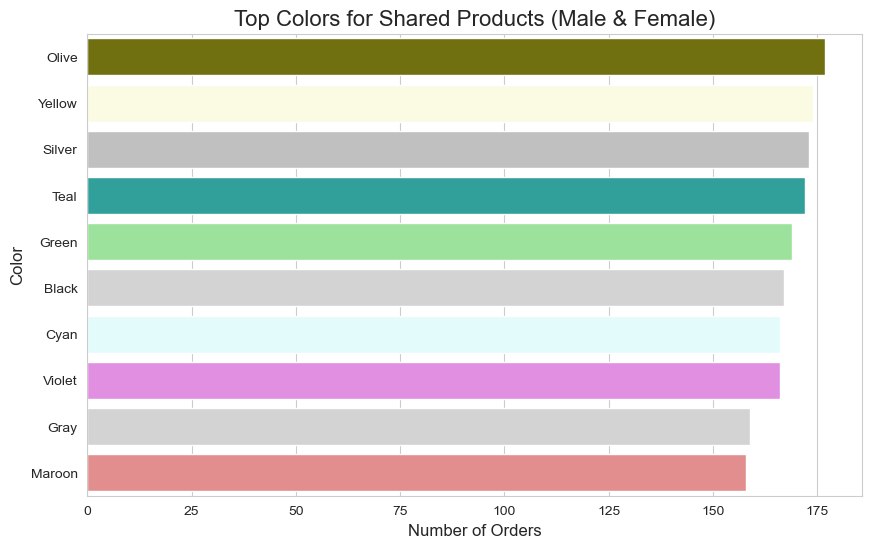

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=common_colors.values,
    y=common_colors.index,
    palette=[color_map.get(c, "lightblue") for c in common_colors.index]
)
plt.title("Top Colors for Shared Products (Male & Female)", fontsize=16)
plt.xlabel("Number of Orders", fontsize=12)
plt.ylabel("Color", fontsize=12)
plt.show()

### Questions for Analyzing Purchase and Payment Behaviour

##### 1. What are the most commonly used payment methods by customers?

In [34]:
# Count the most commonly used payment methods
top_payment_methods = shopping['Payment Method'].value_counts()
print("--- Most Commonly Used Payment Methods ---")
print(top_payment_methods)
print("\n" + "="*50 + "\n")

--- Most Commonly Used Payment Methods ---
Payment Method
Credit Card      696
Venmo            653
Cash             648
PayPal           638
Debit Card       633
Bank Transfer    632
Name: count, dtype: int64




Analysis:

An analysis of the payment methods used by customers shows a remarkably balanced and diverse distribution. Credit Card is the most frequently used method, but only by a very slim margin. All six available payment methods—Credit Card, Venmo, Cash, PayPal, Debit Card, and Bank Transfer—are used almost equally, with usage counts being very close to one another.

Conclusion & Strategic Insight: No Single Dominant Method: The most significant insight is the absence of a single, overwhelmingly preferred payment method. Customers are comfortable using a wide variety of options, which indicates a tech-savvy and flexible customer base. The Importance of Offering Choice: This finding strongly validates the current strategy of offering multiple payment gateways. Removing any of these options, even one that seems less popular like "Bank Transfer," would likely inconvenience a substantial number of customers (over 600 in this dataset) and could lead to cart abandonment and lost sales.

Recommendation: The business should continue to support all existing payment methods. The key takeaway is that choice is critical. Rather than optimizing for a single method, the focus should be on ensuring a smooth, secure, and reliable transaction process for all supported gateways. This diversity in payment options is a key feature and a competitive advantage that caters to the varied preferences of the entire customer base.

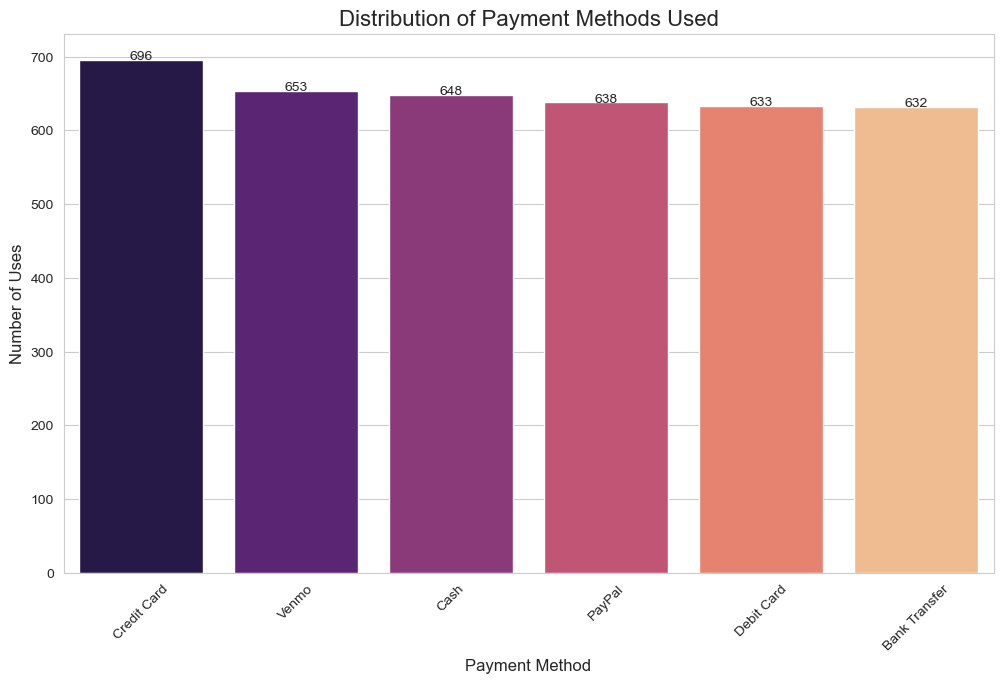

In [35]:
plt.figure(figsize=(12,7))
ax = sns.barplot(x=top_payment_methods.index, y=top_payment_methods.values, palette='magma')

# Add the value on top of each bar
for i, value in enumerate(top_payment_methods.values):
    ax.text(i, value + 0.5, str(value), ha='center', fontsize=10)

plt.title('Distribution of Payment Methods Used', fontsize=16)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Uses', fontsize=12)
plt.xticks(rotation=45)
plt.show()

##### 2. Do customers who use promo codes spend more or less than those who don't?

In [36]:
# Count the number of customers in each group
promo_counts = shopping['Promo Code Used'].value_counts()
print("--- Number of Customers Based on Promo Code Usage ---")
print(promo_counts)
print("\n" + "="*50 + "\n")

# Calculate the percentage of customers in each group
promo_percentage = shopping['Promo Code Used'].value_counts(normalize=True) * 100
print("\n--- Percentage of Customers Based on Promo Code Usage ---")
print(promo_percentage)
print("\n" + "="*50 + "\n")

# Compare the average spending between the two groups
spending_with_promo = shopping.groupby('Promo Code Used')['Purchase Amount (USD)'].mean()
print("\n--- Average Spending Based on Promo Code Usage ---")
print(spending_with_promo)

# Simple conclusion
if spending_with_promo['Yes'] > spending_with_promo['No']:
    print("\nCustomers who use promo codes spend more on average.")
else:
    print("\nCustomers who use promo codes spend less on average.")
print("\n" + "="*50 + "\n")

--- Number of Customers Based on Promo Code Usage ---
Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64



--- Percentage of Customers Based on Promo Code Usage ---
Promo Code Used
No     57.0
Yes    43.0
Name: proportion, dtype: float64



--- Average Spending Based on Promo Code Usage ---
Promo Code Used
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

Customers who use promo codes spend less on average.




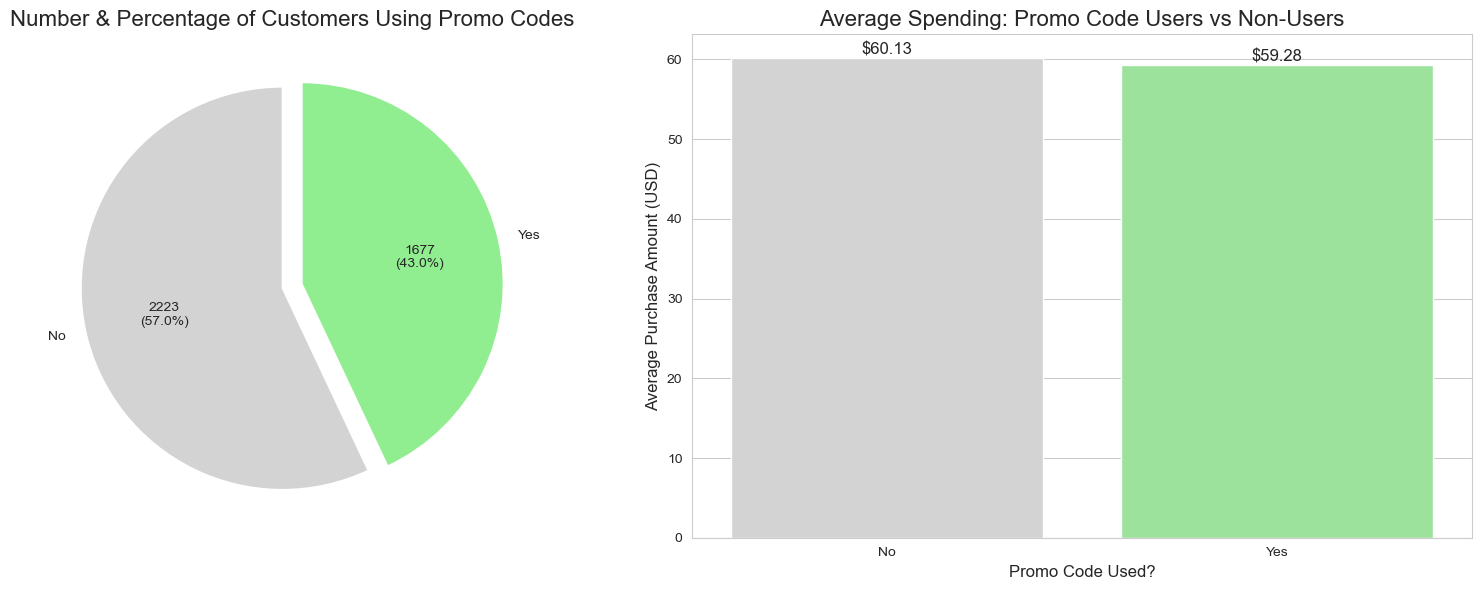

In [37]:
# --- Data: number and percentage of customers ---
promo_counts = shopping['Promo Code Used'].value_counts()
promo_percentage = shopping['Promo Code Used'].value_counts(normalize=True) * 100
spending_with_promo = shopping.groupby('Promo Code Used')['Purchase Amount (USD)'].mean()

# Function to format numbers and percentages in the Pie Chart
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct*total/100.0))
        return f"{count}\n({pct:.1f}%)"
    return my_autopct

# --- Setup figure with 2 subplots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Pie Chart in the first subplot ---
colors = ['lightgray','lightgreen']
axes[0].pie(promo_counts, labels=promo_counts.index, autopct=make_autopct(promo_counts), startangle=90, colors=colors, explode=(0.05, 0.05))
axes[0].set_title('Number & Percentage of Customers Using Promo Codes', fontsize=16)

# --- Bar Plot in the second subplot ---
sns.barplot(x=spending_with_promo.index, y=spending_with_promo.values, palette=colors, ax=axes[1])
for i, value in enumerate(spending_with_promo.values):
    axes[1].text(i, value + 0.5, f"${value:.2f}", ha='center', fontsize=12)
axes[1].set_title('Average Spending: Promo Code Users vs Non-Users', fontsize=16)
axes[1].set_xlabel('Promo Code Used?', fontsize=12)
axes[1].set_ylabel('Average Purchase Amount (USD)', fontsize=12)

plt.tight_layout()
plt.show()

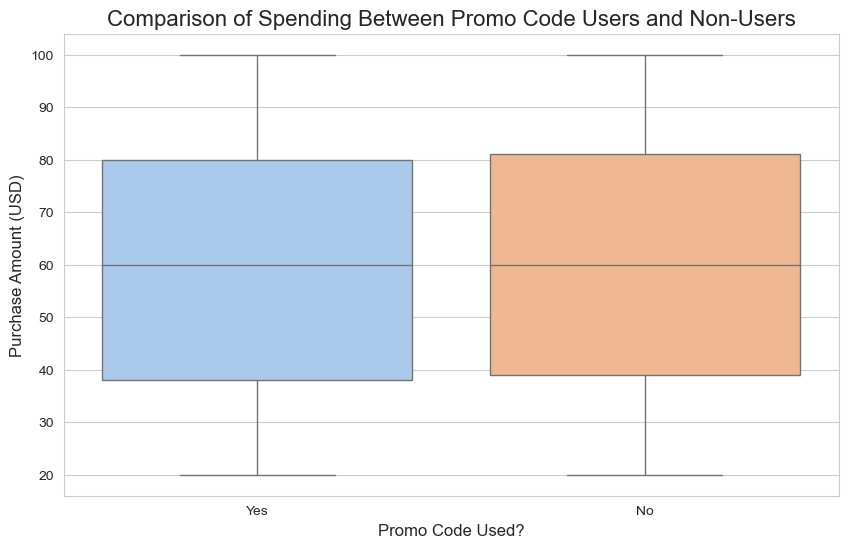

In [38]:
# Use a box plot to compare the spending distribution in both cases
plt.figure(figsize=(10, 6))
sns.boxplot(data=shopping, x='Promo Code Used', y='Purchase Amount (USD)', palette='pastel')
plt.title('Comparison of Spending Between Promo Code Users and Non-Users', fontsize=16)
plt.xlabel('Promo Code Used?', fontsize=12)
plt.ylabel('Purchase Amount (USD)', fontsize=12)
plt.show()

##### 3. What is the purchase frequency rate of customers?

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Calculate the distribution of purchase frequency ---
purchase_frequency = shopping['Frequency of Purchases'].value_counts()
print("--- Distribution of Customer Purchase Frequency ---")
print(purchase_frequency)

--- Distribution of Customer Purchase Frequency ---
Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64


Analysis:

An analysis of the self-reported purchase frequency reveals a remarkably even distribution across all available timeframes. While "Every 3 Months" is technically the most common frequency, the difference in customer numbers between all categories—from "Weekly" to "Annually"—is minimal. This indicates that our customer base is not dominated by a single type of shopper (e.g., frequent, low-value shoppers vs. infrequent, high-value shoppers). Instead, it is a balanced mix of individuals with diverse purchasing habits.

Conclusion & Strategic Insight: Diverse Customer Segments: The primary insight is that we are successfully serving a wide spectrum of customer types. We have loyal, high-frequency customers who purchase weekly, as well as more deliberate, seasonal shoppers who purchase annually. No "One-Size-Fits-All" Marketing Cadence: This data proves that a single marketing communication strategy (e.g., a weekly newsletter for everyone) would be ineffective. Different segments require different engagement strategies.

Recommendation: The business should adopt a segmented marketing approach based on purchase frequency. High-Frequency Segments (Weekly, Bi-Weekly): These customers are highly engaged. They could be targeted with "New Arrivals" notifications, loyalty programs, or early access to sales. Mid-Frequency Segments (Monthly, Quarterly): This group might respond well to monthly trend summaries, style guides, or promotions tied to holidays and events within their purchase window. Low-Frequency Segments (Annually): These customers need a stronger incentive to return. They could be targeted with "We miss you" offers, major seasonal sale announcements, or personalized reminders based on their last purchase. By tailoring communication to match the customer's natural purchasing rhythm, we can increase relevance and drive repeat business more effectively.

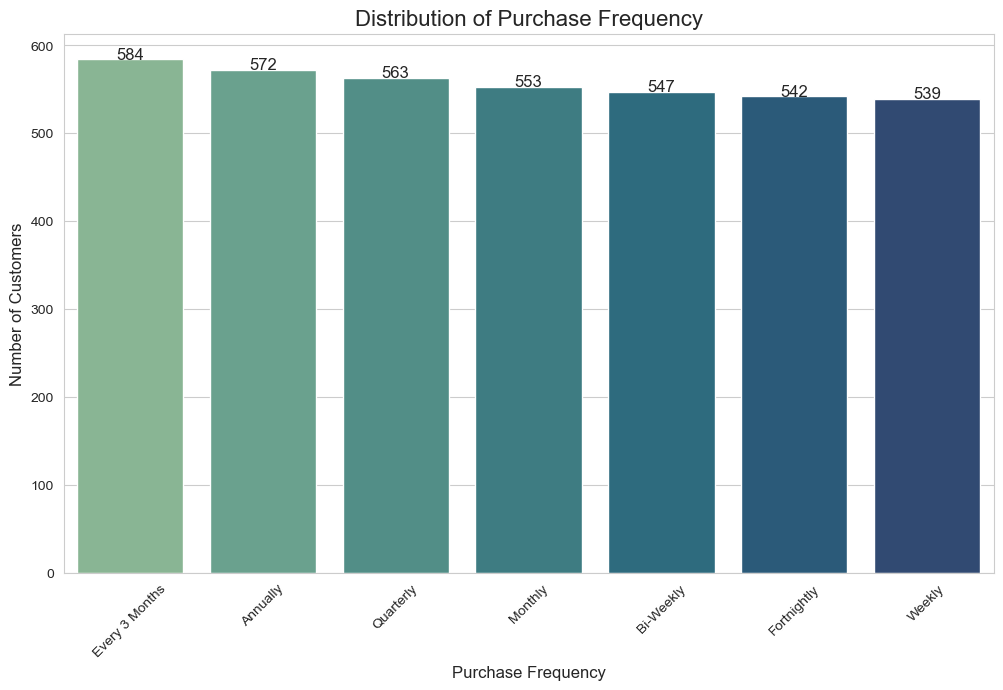

In [40]:
plt.figure(figsize=(12, 7))
ax = sns.countplot(data=shopping, x='Frequency of Purchases', palette='crest', order=purchase_frequency.index)

# Add the numbers on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.5, int(height), ha='center', fontsize=12)

plt.title('Distribution of Purchase Frequency', fontsize=16)
plt.xlabel('Purchase Frequency', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.show()

##### 4. Do subscribed customers have a higher number of previous purchases?

In [41]:
# --- Average number of previous purchases for each group ---
avg_previous_purchases = shopping.groupby('Subscription Status')['Previous Purchases'].mean()
print("--- Average Previous Purchases by Subscription Status ---")
print(avg_previous_purchases)

# --- Simple conclusion ---
if avg_previous_purchases['Yes'] > avg_previous_purchases['No']:
    print("\nSubscribed customers (Yes) have a higher number of previous purchases on average.")
else:
    print("\nSubscribed customers (Yes) have a lower number of previous purchases on average.")

--- Average Previous Purchases by Subscription Status ---
Subscription Status
No     25.080436
Yes    26.084520
Name: Previous Purchases, dtype: float64

Subscribed customers (Yes) have a higher number of previous purchases on average.


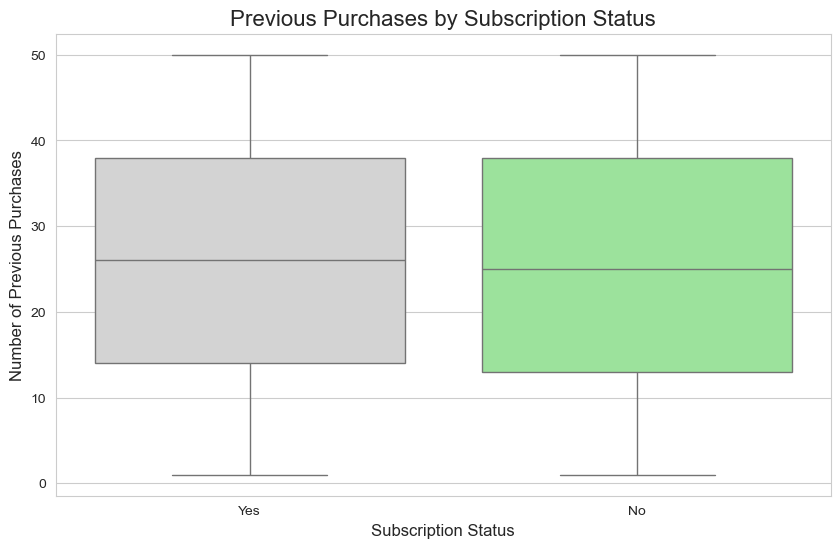

In [42]:
# --- Box Plot with correct colors ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=shopping, x='Subscription Status', y='Previous Purchases',
            palette=['lightgray','lightgreen'])  # Passing a list of colors for each category
plt.title('Previous Purchases by Subscription Status', fontsize=16)
plt.xlabel('Subscription Status', fontsize=12)
plt.ylabel('Number of Previous Purchases', fontsize=12)
plt.show()

### Questions for Assessing Customer Satisfaction and Loyalty <br>

##### 1. What is the average product rating? Are there any products with significantly low ratings?

In [43]:
# --- Calculate the overall average rating ---
average_rating = shopping['Review Rating'].mean()
print(f"The average product rating is: {average_rating:.2f} out of 5")

# --- Top 10 lowest-rated products ---
lowest_rated_items = shopping.groupby('Item Purchased')['Review Rating'].mean().sort_values(ascending=True).head(10)
print("\n" + "="*50 + "\n")
print("--- Top 10 Lowest-Rated Products ---")
print(lowest_rated_items)

The average product rating is: 3.75 out of 5


--- Top 10 Lowest-Rated Products ---
Item Purchased
Shirt         3.629586
Jeans         3.648387
Blouse        3.683626
Scarf         3.700000
Shorts        3.711465
Pants         3.718713
Hoodie        3.719205
Coat          3.730435
Sunglasses    3.744720
Shoes         3.747333
Name: Review Rating, dtype: float64


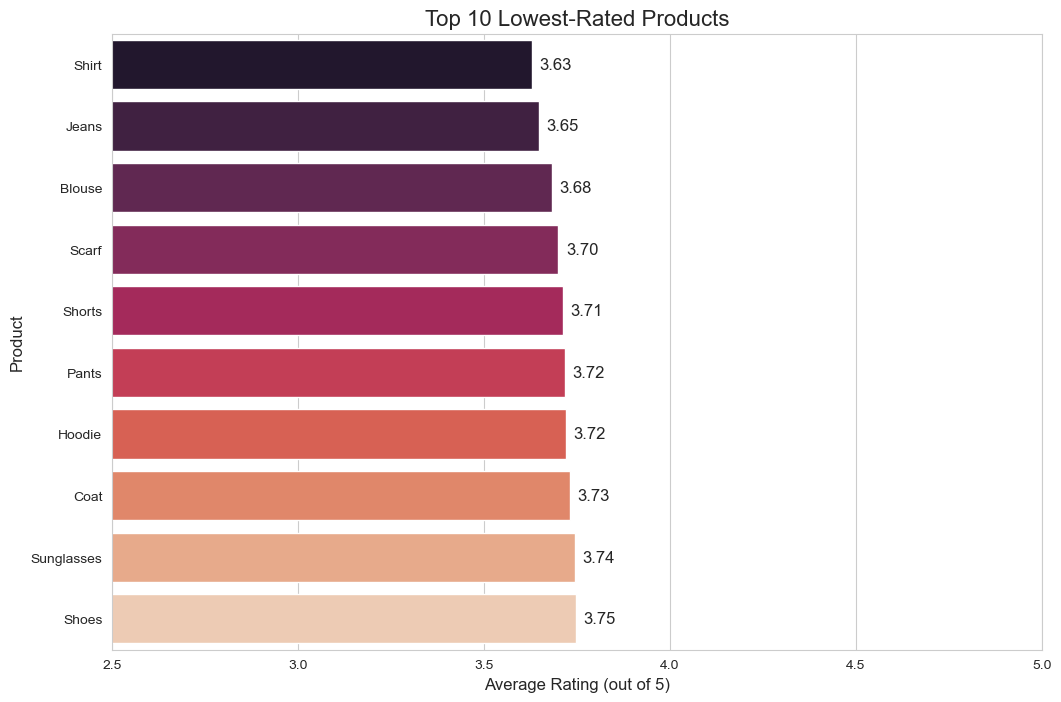

In [44]:
# --- Horizontal bar plot with values on each bar ---
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=lowest_rated_items.values, y=lowest_rated_items.index, palette='rocket')

# Add the values on top of each bar
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.02, p.get_y() + p.get_height()/2, f"{width:.2f}", va='center', fontsize=12)

plt.title('Top 10 Lowest-Rated Products', fontsize=16)
plt.xlabel('Average Rating (out of 5)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.xlim(2.5, 5)  # Set x-axis to start from the minimum possible rating
plt.show()

##### 2. Is there a correlation between the shipping method used and customer ratings?

--- Average Rating by Shipping Method ---
Shipping Type
Standard          3.817737
Express           3.776935
2-Day Shipping    3.761085
Next Day Air      3.720833
Free Shipping     3.717926
Store Pickup      3.706462
Name: Review Rating, dtype: float64


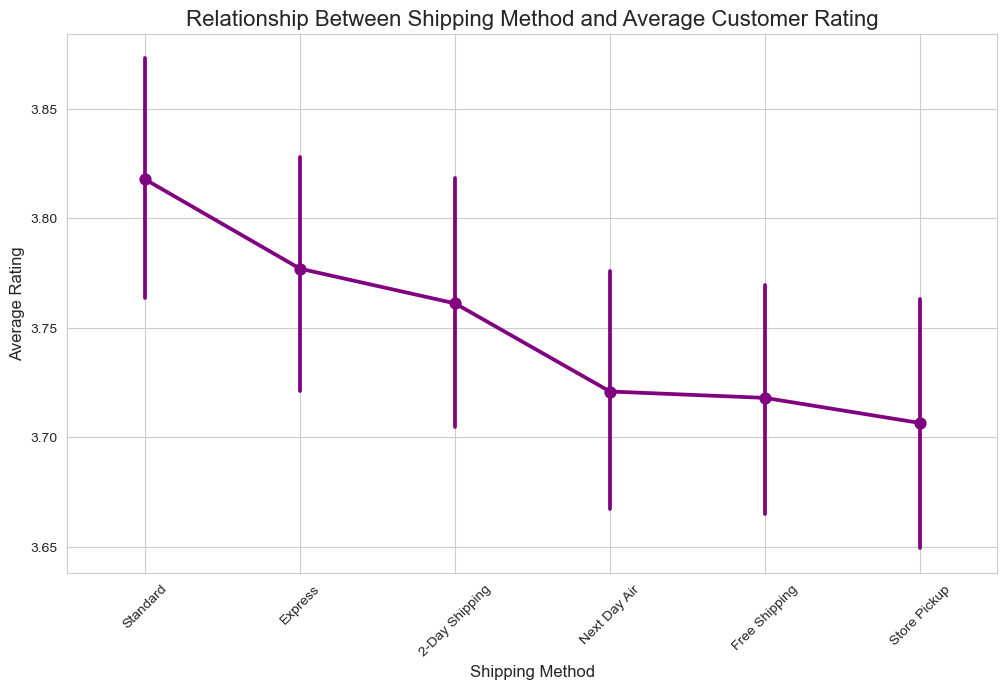

In [45]:
# Compare the average rating for each shipping method
rating_by_shipping = shopping.groupby('Shipping Type')['Review Rating'].mean().sort_values(ascending=False)
print("--- Average Rating by Shipping Method ---")
print(rating_by_shipping)

# Use a point plot or bar plot to compare
plt.figure(figsize=(12, 7))
sns.pointplot(data=shopping, x='Shipping Type', y='Review Rating', order=rating_by_shipping.index, color='purple')
plt.title('Relationship Between Shipping Method and Average Customer Rating', fontsize=16)
plt.xlabel('Shipping Method', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

##### 3. What is the percentage of customers with an active subscription? Are these customers more loyal (making purchases more frequently)?

In [46]:
# a) Calculate the percentage of subscribed customers
subscription_percentage = shopping['Subscription Status'].value_counts(normalize=True) * 100
print("--- Customer Percentage by Subscription Status ---")
print(subscription_percentage)

# b) Analyze purchase frequency for subscribed vs non-subscribed customers
loyalty_by_subscription = shopping.groupby('Subscription Status')['Frequency of Purchases'].agg(lambda x: x.mode()[0])
print("\n" + "="*50 + "\n")
print("--- Most Common Purchase Frequency for Each Group ---")
print(loyalty_by_subscription)
print("\n" + "="*50 + "\n")

--- Customer Percentage by Subscription Status ---
Subscription Status
No     73.0
Yes    27.0
Name: proportion, dtype: float64


--- Most Common Purchase Frequency for Each Group ---
Subscription Status
No     Every 3 Months
Yes          Annually
Name: Frequency of Purchases, dtype: object




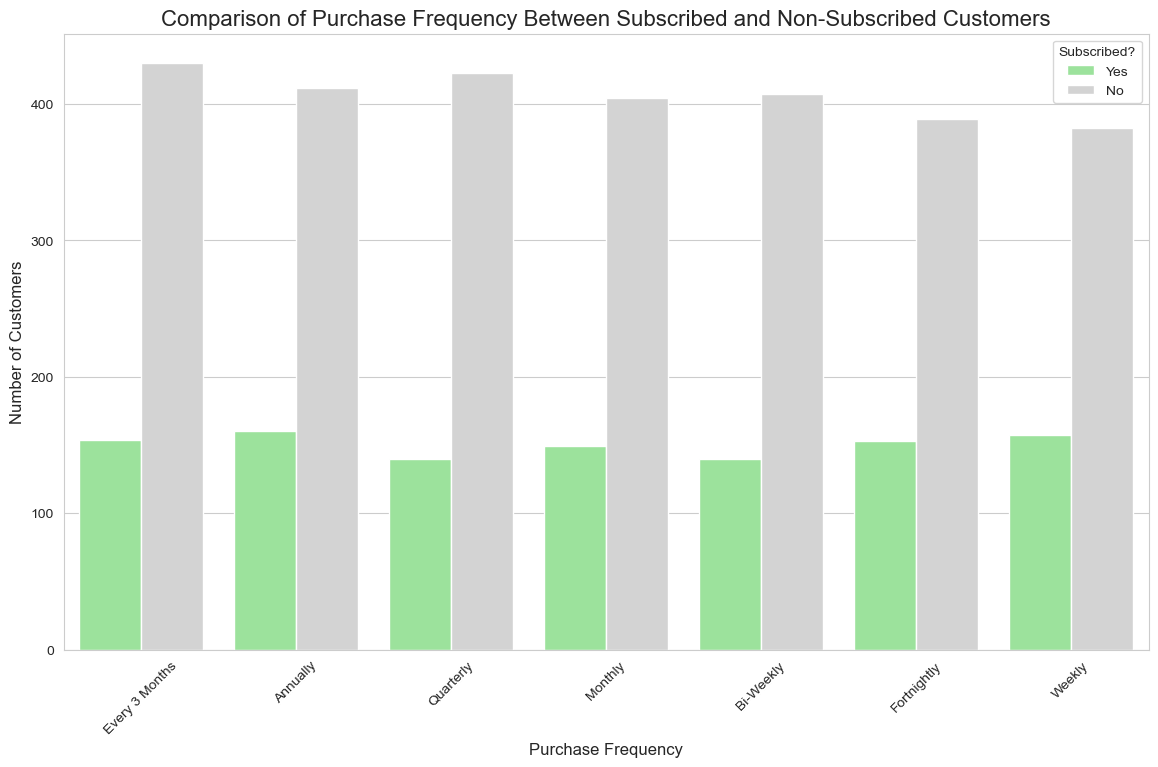

In [47]:
# Stacked bar plot showing purchase frequency distribution for each subscription status
plt.figure(figsize=(14, 8))
sns.countplot(data=shopping, x='Frequency of Purchases', hue='Subscription Status',
              order=shopping['Frequency of Purchases'].value_counts().index,  # order by most common
              palette={'No': 'lightgray', 'Yes': 'lightgreen'})
plt.title('Comparison of Purchase Frequency Between Subscribed and Non-Subscribed Customers', fontsize=16)
plt.xlabel('Purchase Frequency', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Subscribed?')
plt.show()